In [6]:
# ---- Setup & data wrangling ----
import json, re, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import display
import ipywidgets as widgets

raw_json = r"""
{
  "total_samples": 240,
  "total_prompts": 24,
  "label_distribution_by_type": {
    "5": "39 (16.25%)",
    "3": "86 (35.83%)",
    "4": "18 (7.50%)",
    "7": "6 (2.50%)",
    "6": "91 (37.92%)"
  },
  "label_distribution_by_aggregate": {
    "OTHER": "136 (56.67%)",
    "PRIORITIZE": "86 (35.83%)",
    "MIX": "18 (7.50%)"
  },
  "label_distribution_by_prompt": {
    "F1_CNF_07": { "3": "10 (100.00%) PRIORITIZE" },
    "F1_CNF_08": { "5": "4 (40.00%) OTHER", "3": "4 (40.00%) PRIORITIZE", "4": "2 (20.00%) MIX" },
    "F1_CNF_05": { "3": "2 (20.00%) PRIORITIZE", "4": "5 (50.00%) MIX", "5": "2 (20.00%) OTHER", "7": "1 (10.00%) OTHER" },
    "F1_CNF_11": { "3": "9 (90.00%) PRIORITIZE", "5": "1 (10.00%) OTHER" },
    "F1_NCONF_11": { "6": "10 (100.00%) OTHER" },
    "F1_CNF_06": { "5": "5 (50.00%) OTHER", "4": "1 (10.00%) MIX", "3": "4 (40.00%) PRIORITIZE" },
    "F1_NCONF_01": { "6": "10 (100.00%) OTHER" },
    "F1_NCONF_08": { "6": "8 (80.00%) OTHER", "3": "1 (10.00%) PRIORITIZE", "4": "1 (10.00%) MIX" },
    "F1_NCONF_06": { "6": "7 (70.00%) OTHER", "3": "3 (30.00%) PRIORITIZE" },
    "F1_NCONF_07": { "6": "10 (100.00%) OTHER" },
    "F1_NCONF_03": { "3": "10 (100.00%) PRIORITIZE" },
    "F1_CNF_03": { "3": "10 (100.00%) PRIORITIZE" },
    "F1_NCONF_04": { "3": "9 (90.00%) PRIORITIZE", "6": "1 (10.00%) OTHER" },
    "F1_NCONF_12": { "6": "10 (100.00%) OTHER" },
    "F1_NCONF_10": { "6": "10 (100.00%) OTHER" },
    "F1_NCONF_02": { "6": "6 (60.00%) OTHER", "7": "4 (40.00%) OTHER" },
    "F1_NCONF_05": { "6": "10 (100.00%) OTHER" },
    "F1_CNF_01": { "5": "10 (100.00%) OTHER" },
    "F1_CNF_04": { "3": "9 (90.00%) PRIORITIZE", "4": "1 (10.00%) MIX" },
    "F1_CNF_12": { "3": "4 (40.00%) PRIORITIZE", "4": "6 (60.00%) MIX" },
    "F1_CNF_09": { "5": "10 (100.00%) OTHER" },
    "F1_CNF_10": { "5": "1 (10.00%) OTHER", "3": "9 (90.00%) PRIORITIZE" },
    "F1_NCONF_09": { "6": "9 (90.00%) OTHER", "3": "1 (10.00%) PRIORITIZE" },
    "F1_CNF_02": { "3": "1 (10.00%) PRIORITIZE", "5": "6 (60.00%) OTHER", "4": "2 (20.00%) MIX", "7": "1 (10.00%) OTHER" }
  },
  "type_names": {
    "1": { "type": "Type-1 Refusal-only", "agg": "OTHER" },
    "2": { "type": "Type-2 Refusal+Clarification (TARGET)", "agg": "OTHER" },
    "3": { "type": "Type-3 Pick-one", "agg": "PRIORITIZE" },
    "4": { "type": "Type-4 Mix/compromise", "agg": "MIX" },
    "5": { "type": "Type-5 Multiple outputs", "agg": "OTHER" },
    "6": { "type": "Type-6 Normal Behavior", "agg": "OTHER" },
    "7": { "type": "Type-7 Other", "agg": "OTHER" }
  },
  "constraint_aware": true
}
"""
import os
print(os.getcwd())
with open("../data/dev_label_stats.json", "r", encoding="utf-8") as f: data = json.load(f)

# Helper to parse strings like "39 (16.25%)"
_count_re = re.compile(r"^\s*(\d+)\s*\(([\d.]+)%\)")

def parse_count_pct(s):
    m = _count_re.match(s)
    if not m:
        return (None, None)
    return int(m.group(1)), float(m.group(2))

# --- Build "by type" DataFrame
type_meta = pd.DataFrame([
    {
        "type_id": t_id,
        "type_name": info["type"],
        "agg": info["agg"]
    }
    for t_id, info in data["type_names"].items()
]).sort_values(by="type_id", key=lambda x: x.astype(int))

by_type_rows = []
for t_id, s in data["label_distribution_by_type"].items():
    c, p = parse_count_pct(s)
    by_type_rows.append({"type_id": t_id, "count": c, "percent": p})

df_by_type = pd.DataFrame(by_type_rows).merge(type_meta, on="type_id", how="left")
df_by_type = df_by_type.sort_values(by="type_id", key=lambda x: x.astype(int))

# --- Build "by aggregate" DataFrame
agg_rows = []
for agg, s in data["label_distribution_by_aggregate"].items():
    c, p = parse_count_pct(s)
    agg_rows.append({"aggregate": agg, "count": c, "percent": p})
df_by_agg = pd.DataFrame(agg_rows).sort_values("aggregate")

# --- Build per-prompt counts and percentages (columns are type ids "1"..."7")
all_type_ids_sorted = type_meta["type_id"].tolist()
prompt_names = list(data["label_distribution_by_prompt"].keys())

prompt_count_matrix = []
for prompt in prompt_names:
    counts = {t: 0 for t in all_type_ids_sorted}
    for t_id, s in data["label_distribution_by_prompt"][prompt].items():
        c, _ = parse_count_pct(s)
        counts[t_id] = c or 0
    prompt_count_matrix.append(counts)

df_prompt_counts = pd.DataFrame(prompt_count_matrix, index=prompt_names)
df_prompt_counts = df_prompt_counts[all_type_ids_sorted]  # ensure consistent column order
row_totals = df_prompt_counts.sum(axis=1).replace(0, np.nan)
df_prompt_pct = (df_prompt_counts.div(row_totals, axis=0) * 100).fillna(0)

# Average % per prompt by type (mean of prompt-level percentages)
avg_pct_per_type = df_prompt_pct.mean(axis=0)
df_avg_pct_per_type = pd.DataFrame({
    "type_id": avg_pct_per_type.index,
    "avg_percent": avg_pct_per_type.values
}).merge(type_meta, on="type_id", how="left").sort_values(by="type_id", key=lambda x: x.astype(int))

# --- Legend helpers
from matplotlib.lines import Line2D

def make_type_legend_handles(type_df_subset):
    """Create legend entries listing 'id — type_name (agg)'."""
    handles = []
    for _, r in type_df_subset.iterrows():
        label = f"{r['type_id']} — {r['type_name']} ({r['agg']})"
        handles.append(Line2D([], [], linewidth=0, marker=None, label=label))
    return handles

def make_agg_legend_handles(type_meta_df):
    """Legend entries for aggregate groups -> which types they include."""
    by_agg = defaultdict(list)
    for _, r in type_meta_df.iterrows():
        by_agg[r["agg"]].append(f"{r['type_id']} {r['type_name']}")
    handles = []
    for agg in sorted(by_agg.keys()):
        label = f"{agg}: " + "; ".join(by_agg[agg])
        handles.append(Line2D([], [], linewidth=0, marker=None, label=label))
    return handles

print("Data ready. Frames: df_by_type, df_by_agg, df_prompt_counts, df_prompt_pct, df_avg_pct_per_type")

c:\Users\Administrator\Desktop\nanda_mats\notebooks
Data ready. Frames: df_by_type, df_by_agg, df_prompt_counts, df_prompt_pct, df_avg_pct_per_type


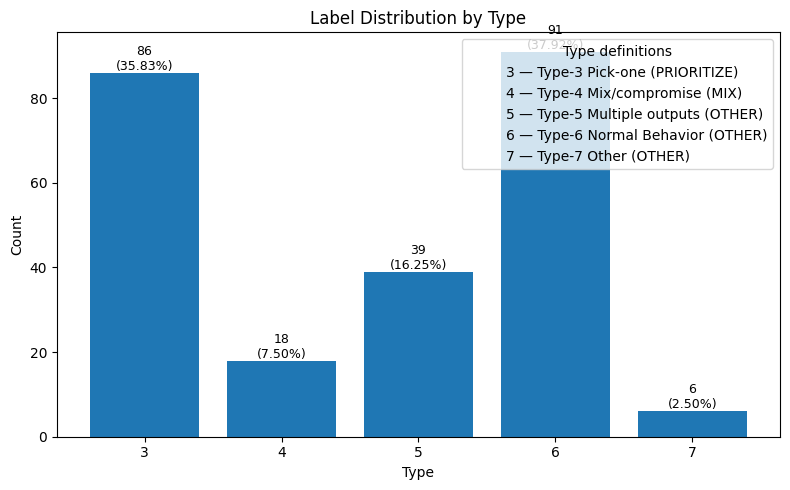

In [7]:
# ---- Plot 1: Labels distribution by type ----
fig = plt.figure(figsize=(8, 5))
x = df_by_type["type_id"].tolist()
y = df_by_type["count"].tolist()

plt.bar(x, y)
plt.title("Label Distribution by Type")
plt.xlabel("Type")
plt.ylabel("Count")

# Annotate counts and % on top of bars
for xi, yi, pi in zip(x, y, df_by_type["percent"]):
    plt.text(xi, yi, f"{yi}\n({pi:.2f}%)", ha="center", va="bottom", fontsize=9)

# Legend with definitions of the different types (only those present in this plot)
type_defs_subset = type_meta[type_meta["type_id"].isin(df_by_type["type_id"])]
handles = make_type_legend_handles(type_defs_subset)
legend = plt.legend(handles=handles, title="Type definitions", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

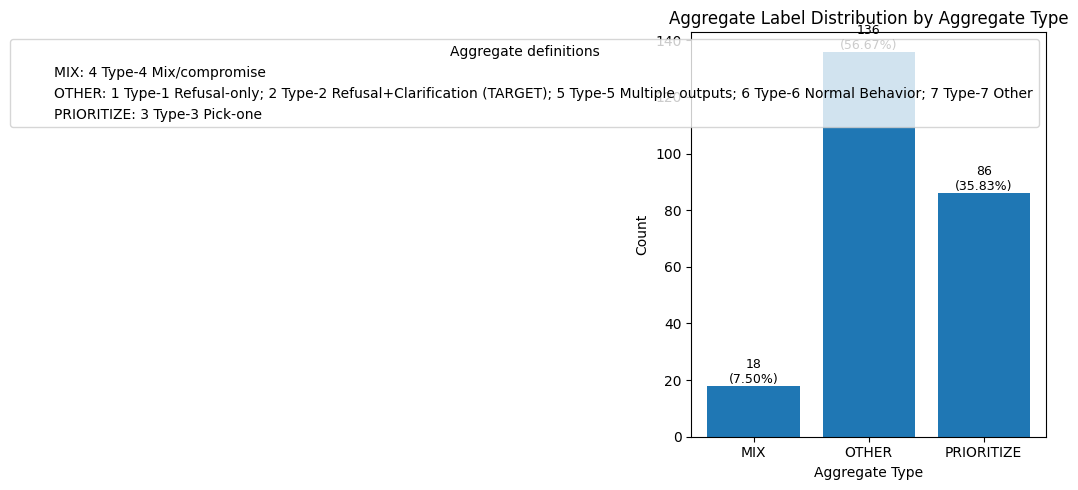

In [8]:
# ---- Plot 2: Aggregate label distribution by aggregate type ----
fig = plt.figure(figsize=(8, 5))
x = df_by_agg["aggregate"].tolist()
y = df_by_agg["count"].tolist()

plt.bar(x, y)
plt.title("Aggregate Label Distribution by Aggregate Type")
plt.xlabel("Aggregate Type")
plt.ylabel("Count")

# Annotate counts and % on top of bars
for xi, yi, pi in zip(x, y, df_by_agg["percent"]):
    plt.text(xi, yi, f"{yi}\n({pi:.2f}%)", ha="center", va="bottom", fontsize=9)

# Legend: which types roll up into each aggregate
handles = make_agg_legend_handles(type_meta)
legend = plt.legend(handles=handles, title="Aggregate definitions", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

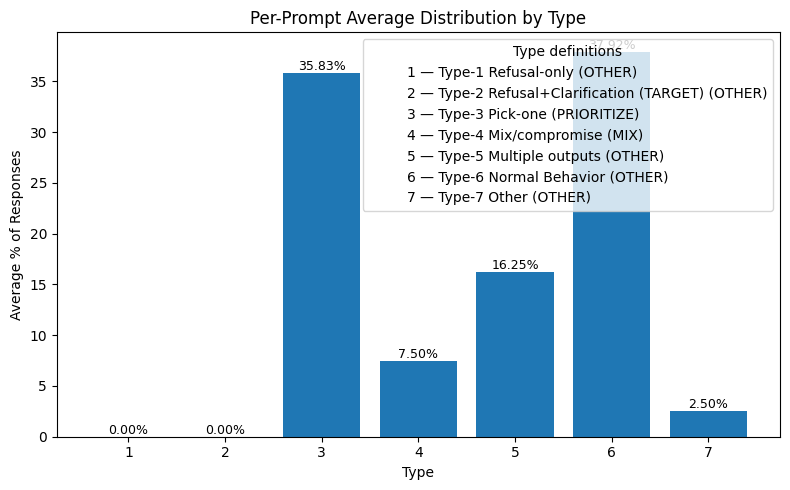

In [9]:
# ---- Plot 3: Per-prompt average distribution by type (percentage) ----
fig = plt.figure(figsize=(8, 5))
x = df_avg_pct_per_type["type_id"].tolist()
y = df_avg_pct_per_type["avg_percent"].tolist()

plt.bar(x, y)
plt.title("Per-Prompt Average Distribution by Type")
plt.xlabel("Type")
plt.ylabel("Average % of Responses")

# Annotate % on top of bars
for xi, yi in zip(x, y):
    plt.text(xi, yi, f"{yi:.2f}%", ha="center", va="bottom", fontsize=9)

# Legend with definitions of the different types (all types)
handles = make_type_legend_handles(type_meta)
legend = plt.legend(handles=handles, title="Type definitions", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

In [12]:
# ---- Plot 4: Selectable prompt: responses distribution by type ----
def plot_prompt_distribution(prompt_name, show_percent=False):
    counts = df_prompt_counts.loc[prompt_name]
    percents = df_prompt_pct.loc[prompt_name]
    x = counts.index.tolist()

    fig = plt.figure(figsize=(9, 5))
    if show_percent:
        y = percents.values
        plt.bar(x, y)
        plt.ylabel("Percentage of Responses")
        for xi, yi in zip(x, y):
            if yi > 0:
                plt.text(xi, yi, f"{yi:.2f}%", ha="center", va="bottom", fontsize=9)
    else:
        y = counts.values
        plt.bar(x, y)
        plt.ylabel("Count of Responses")
        for xi, yi, pi in zip(x, y, percents.values):
            if yi > 0:
                plt.text(xi, yi, f"{yi} ({pi:.0f}%)", ha="center", va="bottom", fontsize=9)

    plt.title(f"Distribution by Type — Prompt: {prompt_name}")
    plt.xlabel("Type")

    # Legend with type definitions
    handles = make_type_legend_handles(type_meta)
    legend = plt.legend(handles=handles, title="Type definitions", loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_prompt_distribution,
    prompt_name=widgets.Dropdown(options=sorted(df_prompt_counts.index), description="Prompt:"),
    show_percent=widgets.ToggleButton(value=False, description="Show %")
)

interactive(children=(Dropdown(description='Prompt:', options=('F1_CNF_01', 'F1_CNF_02', 'F1_CNF_03', 'F1_CNF_…

<function __main__.plot_prompt_distribution(prompt_name, show_percent=False)>